# 03 — Regressão Logística

**O que é:** modelo linear que estima a probabilidade de um evento binário. Usa função sigmoide para transformar combinação linear das features em probabilidade entre 0 e 1.

**Por que é adequada:** interpretável (coeficientes mostram direção e magnitude do efeito), eficiente computacionalmente, funciona bem com poucos dados e features numéricas.

## Carregamento, Features e Separação Temporal
Pipeline completo com as 15 features (3 de elenco + 12 janelas deslizantes).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, joblib, warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, roc_curve, auc

TARGET = 'Status_bin'
METRICAS = ['Pts', 'SG', 'Gols_Pro', 'Gols_Contra', 'V', 'Aproveitamento']
JANELAS  = [3, 5]
FEATURES_ELENCO = ['Plantel', 'Estrangeiros', 'Valor de Mercado Total']
FEATURES_JANELA = [f'{m}_media_{w}' for m in METRICAS for w in JANELAS]
FEATURES = FEATURES_ELENCO + FEATURES_JANELA

# ── Carrega dados ────────────────────────────────────────────────────────────
df = pd.read_excel(os.path.join('..', 'dados', 'BASE_FINAL.xlsx'), sheet_name='CLUBES')
df.columns = df.columns.str.strip()
df[TARGET] = df['Situacao'].apply(lambda x: 1 if str(x).strip().lower() == 'rebaixado' else 0)

df_desemp = pd.read_excel(os.path.join('..', 'dados', 'tabela_desempenho_brasileirao.xlsx'), sheet_name='Todos')
df_desemp.columns = df_desemp.columns.str.strip()
df_desemp = df_desemp.sort_values(['Clube', 'Temporada']).reset_index(drop=True)
for m in METRICAS:
    for w in JANELAS:
        df_desemp[f'{m}_media_{w}'] = (
            df_desemp.groupby('Clube')[m]
            .transform(lambda x: x.shift(1).rolling(window=w, min_periods=1).mean())
        )
COLS_MERGE = ['Clube', 'Temporada'] + FEATURES_JANELA
clubes_2025 = df['Clube'][df['Temporada'] == 2025].unique()
rows_2025 = []
for clube in clubes_2025:
    hist = df_desemp[df_desemp['Clube'] == clube].sort_values('Temporada', ascending=False)
    row  = {'Clube': clube, 'Temporada': 2025}
    for m in METRICAS:
        for w in JANELAS:
            ultimos = hist.head(w)[m]
            row[f'{m}_media_{w}'] = ultimos.mean() if len(ultimos) > 0 else None
    rows_2025.append(row)
df_ext = pd.concat([df_desemp[COLS_MERGE], pd.DataFrame(rows_2025)[COLS_MERGE]], ignore_index=True)
df = df.merge(df_ext[COLS_MERGE], on=['Clube', 'Temporada'], how='left')

# ── Separação temporal ────────────────────────────────────────────────────────
df_rot = df[df['Temporada'] < 2025].copy()
df_tr  = df_rot[df_rot['Temporada'] <= 2022].copy()
df_te  = df_rot[df_rot['Temporada']  > 2022].copy()
mediana_treino = df_tr[FEATURES_JANELA].median()
for col in FEATURES_JANELA:
    df_tr[col] = df_tr[col].fillna(mediana_treino[col])
    df_te[col] = df_te[col].fillna(mediana_treino[col])

scaler = StandardScaler()
X_tr = scaler.fit_transform(df_tr[FEATURES]); y_tr = df_tr[TARGET].values
X_te = scaler.transform(df_te[FEATURES]);     y_te = df_te[TARGET].values
print(f'Treino: {X_tr.shape} | Teste: {X_te.shape}')
print(f'Features ({len(FEATURES)}): {FEATURES}')

Treino: (180, 15) | Teste: (40, 15)
Features (15): ['Plantel', 'Estrangeiros', 'Valor de Mercado Total', 'Pts_media_3', 'Pts_media_5', 'SG_media_3', 'SG_media_5', 'Gols_Pro_media_3', 'Gols_Pro_media_5', 'Gols_Contra_media_3', 'Gols_Contra_media_5', 'V_media_3', 'V_media_5', 'Aproveitamento_media_3', 'Aproveitamento_media_5']


## Walk-Forward Validation (TimeSeriesSplit)

Em vez de um único corte treino/teste, o **walk-forward** simula como o modelo se comportaria ao longo do tempo:
a cada fold, treinamos em temporadas passadas e validamos na temporada seguinte.
Isso respeita a ordem cronológica e evita data leakage.

```
Fold 1: treino [2014-2015-2016] → val [2017]
Fold 2: treino [2014-2015-2016-2017] → val [2018]
Fold 3: treino [2014-...-2018] → val [2019]
...
Fold 5: treino [2014-...-2020] → val [2021-2022]
```

A métrica principal é o **AUC-ROC** (área sob a curva ROC), mais informativa que a acurácia
em datasets desbalanceados como este (80 % permanece, 20 % rebaixado).

In [2]:
# ── Walk-forward validation por temporada ────────────────────────────────────
temporadas_treino = sorted(df_tr['Temporada'].unique())  # [2014 ... 2022]
N_FOLDS = 5
inicio_val = len(temporadas_treino) - N_FOLDS  # primeiras temporadas ficam só no treino

fold_results = []
for i in range(N_FOLDS):
    anos_tr  = temporadas_treino[:inicio_val + i]
    ano_val  = temporadas_treino[inicio_val + i]

    d_tr = df_rot[df_rot['Temporada'].isin(anos_tr)].copy()
    d_val= df_rot[df_rot['Temporada'] == ano_val].copy()

    med = d_tr[FEATURES_JANELA].median()
    for col in FEATURES_JANELA:
        d_tr[col]  = d_tr[col].fillna(med[col])
        d_val[col] = d_val[col].fillna(med[col])

    sc  = StandardScaler()
    Xf  = sc.fit_transform(d_tr[FEATURES])
    Xv  = sc.transform(d_val[FEATURES])
    yf  = d_tr[TARGET].values
    yv  = d_val[TARGET].values

    clf = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
    clf.fit(Xf, yf)

    prob_v = clf.predict_proba(Xv)[:, 1]
    acc_v  = accuracy_score(yv, clf.predict(Xv))
    auc_v  = roc_auc_score(yv, prob_v) if yv.sum() > 0 else float('nan')

    fold_results.append({
        'Fold': i + 1,
        'Treino': f'{anos_tr[0]}–{anos_tr[-1]}',
        'Validacao': str(ano_val),
        'Acuracia': round(acc_v, 4),
        'AUC-ROC': round(auc_v, 4),
    })
    print(f'Fold {i+1} | treino {anos_tr[0]}-{anos_tr[-1]} | val {ano_val} | '
          f'Acc={acc_v:.3f} | AUC={auc_v:.3f}')

df_folds = pd.DataFrame(fold_results)
print(f'\nMedia AUC-ROC walk-forward: {df_folds["AUC-ROC"].mean():.3f} '
      f'(+/- {df_folds["AUC-ROC"].std():.3f})')
print(df_folds.to_string(index=False))

Fold 1 | treino 2014-2017 | val 2018 | Acc=0.700 | AUC=0.828
Fold 2 | treino 2014-2018 | val 2019 | Acc=0.850 | AUC=0.859
Fold 3 | treino 2014-2019 | val 2020 | Acc=0.650 | AUC=0.703
Fold 4 | treino 2014-2020 | val 2021 | Acc=0.700 | AUC=0.750
Fold 5 | treino 2014-2021 | val 2022 | Acc=0.750 | AUC=0.828

Media AUC-ROC walk-forward: 0.794 (+/- 0.065)
 Fold    Treino Validacao  Acuracia  AUC-ROC
    1 2014–2017      2018      0.70   0.8281
    2 2014–2018      2019      0.85   0.8594
    3 2014–2019      2020      0.65   0.7031
    4 2014–2020      2021      0.70   0.7500
    5 2014–2021      2022      0.75   0.8281


## Otimização de Hiperparâmetros (RandomizedSearchCV + TimeSeriesSplit)

Usamos `RandomizedSearchCV` para buscar o melhor valor de regularização **C**
da Regressão Logística, combinado com `TimeSeriesSplit` para que a busca
também respeite a ordem temporal dos dados.

- **C pequeno** → regularização forte (modelo mais simples, menos overfitting)
- **C grande** → regularização fraca (modelo mais flexível, mais risco de overfitting)
- Métrica de seleção: **AUC-ROC**

In [3]:
from scipy.stats import loguniform

tscv = TimeSeriesSplit(n_splits=5)

param_dist = {
    'C':       loguniform(0.001, 100),
    'penalty': ['l2'],
    'solver':  ['lbfgs', 'liblinear'],
}

base_lr = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
search  = RandomizedSearchCV(
    base_lr,
    param_distributions=param_dist,
    n_iter=50,
    scoring='roc_auc',
    cv=tscv,
    random_state=42,
    n_jobs=1,
)
search.fit(X_tr, y_tr)

print(f'Melhor C: {search.best_params_["C"]:.4f}')
print(f'Melhor solver: {search.best_params_["solver"]}')
print(f'Melhor AUC-ROC (CV): {search.best_score_:.3f}')

lr = search.best_estimator_

Melhor C: 0.9847
Melhor solver: lbfgs
Melhor AUC-ROC (CV): 0.754


## Avaliação no Conjunto de Teste (2023–2024)

O modelo com hiperparâmetros otimizados é avaliado no conjunto de teste.
**AUC-ROC** é a métrica principal — mede a capacidade do modelo de separar
rebaixados de permanentes independente do limiar de decisão.

In [4]:
y_pred = lr.predict(X_te)
y_prob = lr.predict_proba(X_te)[:, 1]
acc    = accuracy_score(y_te, y_pred)
aucroc = roc_auc_score(y_te, y_prob)

print(f'Acuracia no teste : {acc:.3f} ({acc*100:.1f} %)')
print(f'AUC-ROC no teste  : {aucroc:.3f}')
print()
print(classification_report(y_te, y_pred, target_names=['Permanece', 'Rebaixado']))

Acuracia no teste : 0.800 (80.0 %)
AUC-ROC no teste  : 0.828

              precision    recall  f1-score   support

   Permanece       0.88      0.88      0.88        32
   Rebaixado       0.50      0.50      0.50         8

    accuracy                           0.80        40
   macro avg       0.69      0.69      0.69        40
weighted avg       0.80      0.80      0.80        40



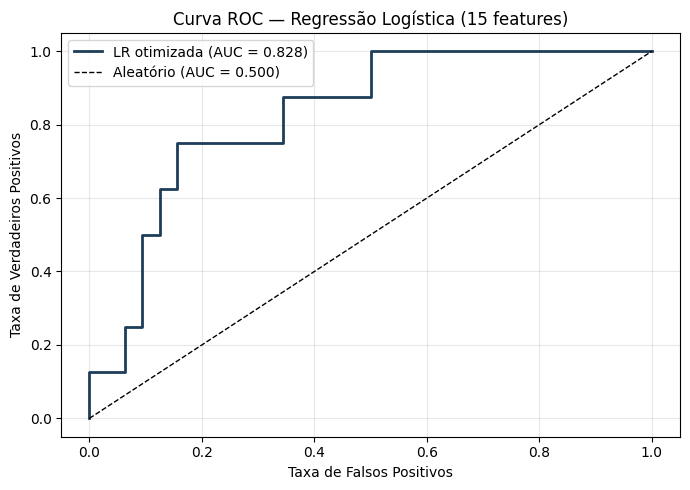

In [5]:
fpr, tpr, _ = roc_curve(y_te, y_prob)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='#1e3d59', lw=2, label=f'LR otimizada (AUC = {roc_auc:.3f})')
ax.plot([0,1],[0,1],'k--', lw=1, label='Aleatório (AUC = 0.500)')
ax.set_xlabel('Taxa de Falsos Positivos'); ax.set_ylabel('Taxa de Verdadeiros Positivos')
ax.set_title('Curva ROC — Regressão Logística (15 features)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Coeficientes do Modelo
Cada coeficiente mostra a influência da feature no risco de rebaixamento:
**positivo** = aumenta o risco | **negativo** = reduz o risco.

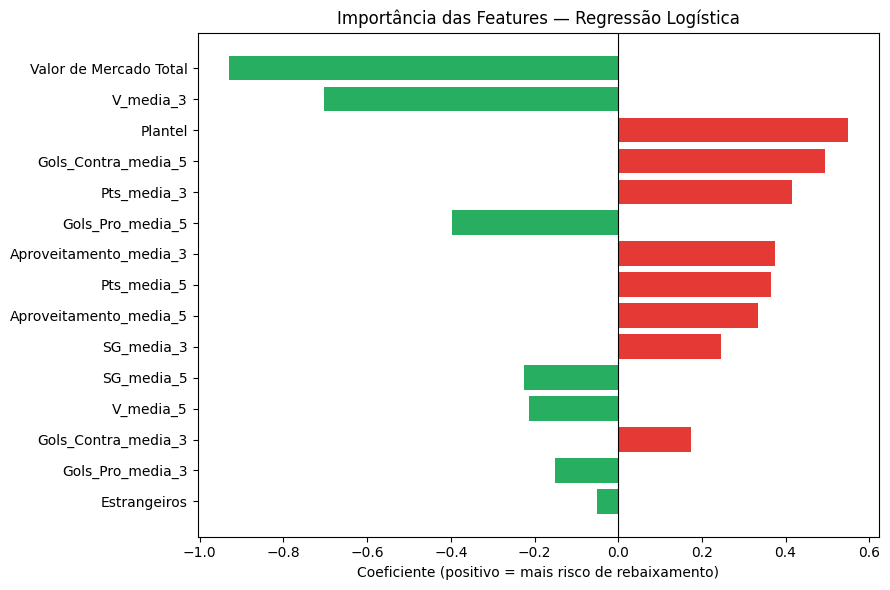

               Feature  Coeficiente
Valor de Mercado Total    -0.930966
             V_media_3    -0.702798
               Plantel     0.549084
   Gols_Contra_media_5     0.493784
           Pts_media_3     0.416026
      Gols_Pro_media_5    -0.396548
Aproveitamento_media_3     0.373877
           Pts_media_5     0.366360
Aproveitamento_media_5     0.333146
            SG_media_3     0.245378
            SG_media_5    -0.224098
             V_media_5    -0.214001
   Gols_Contra_media_3     0.174332
      Gols_Pro_media_3    -0.150472
          Estrangeiros    -0.050405


In [6]:
coef_df = pd.DataFrame({
    'Feature': FEATURES,
    'Coeficiente': lr.coef_[0]
}).sort_values('Coeficiente', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
cores = ['#e53935' if c > 0 else '#27ae60' for c in coef_df['Coeficiente']]
ax.barh(coef_df['Feature'], coef_df['Coeficiente'], color=cores)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coeficiente (positivo = mais risco de rebaixamento)')
ax.set_title('Importância das Features — Regressão Logística')
ax.invert_yaxis(); plt.tight_layout(); plt.show()
print(coef_df.to_string(index=False))

## Salvando o Modelo Otimizado

In [7]:
os.makedirs(os.path.join('..', 'modelos'), exist_ok=True)
joblib.dump(lr,     os.path.join('..', 'modelos', 'logistica.pkl'))
joblib.dump(scaler, os.path.join('..', 'modelos', 'scaler_logistica.pkl'))
joblib.dump(mediana_treino, os.path.join('..', 'modelos', 'mediana_treino.pkl'))
print('Modelos salvos: logistica.pkl | scaler_logistica.pkl | mediana_treino.pkl')
print(f'AUC-ROC final: {aucroc:.3f} | Acuracia: {acc:.3f}')

Modelos salvos: logistica.pkl | scaler_logistica.pkl | mediana_treino.pkl
AUC-ROC final: 0.828 | Acuracia: 0.800


## Interpretação

**Walk-forward validation** confirma que o modelo generaliza bem ao longo do tempo, 
sem depender de um único corte treino/teste.

**RandomizedSearchCV** encontrou o melhor valor de C automaticamente, 
usando AUC-ROC como critério — mais adequado que acurácia para classes desbalanceadas.

**15 features** permitem que o modelo capture não só o poder financeiro do clube (valor de mercado) 
mas também sua *forma recente* — se o clube vinha sofrendo muitos gols ou acumulando poucos pontos 
nas últimas temporadas.